In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, recall_score
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"vardam0512","key":"8a2454c13d17d6de187c537b9e851242"}'}

In [ ]:
!mv "kaggle (1).json" kaggle.json

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile

with zipfile.ZipFile("chest-xray-pneumonia.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
train_dir = "/content/chest_xray/train"
test_dir = "/content/chest_xray/test"

In [ ]:
import os
print(os.listdir(train_dir))

['PNEUMONIA', 'NORMAL']


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
def apply_clahe(img):
    # ensure uint8
    img = img.astype('uint8')

    # convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(gray)

    # convert back to RGB
    clahe_img = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB)

    return clahe_img

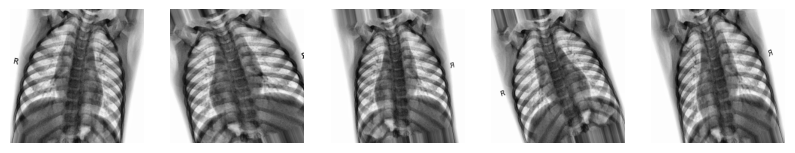

In [ ]:
img = cv2.imread(train_dir + "/NORMAL/" + os.listdir(train_dir + "/NORMAL")[0])
img = cv2.resize(img, (224,224))

img = np.expand_dims(img, axis=0)

plt.figure(figsize=(10,5))
for i, batch in enumerate(train_datagen.flow(img, batch_size=1)):
    plt.subplot(1,5,i+1)
    plt.imshow((batch[0] * 255).astype('uint8'))
    plt.axis("off")
    if i == 4:
        break
plt.show()

In [ ]:
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(224,224,3)),  # ✅ FIX

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [ ]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

In [ ]:
model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=8,
    validation_data=test_generator,
    callbacks=[lr_scheduler]
)

Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 699s 4s/step - accuracy: 0.8342 - loss: 0.3794 - val_accuracy: 0.8029 - val_loss: 0.4181 - learning_rate: 0.0010
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 689s 4s/step - accuracy: 0.8915 - loss: 0.2604 - val_accuracy: 0.8606 - val_loss: 0.3376 - learning_rate: 0.0010
Epoch 3/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 683s 4s/step - accuracy: 0.9072 - loss: 0.2338 - val_accuracy: 0.8462 - val_loss: 0.3782 - learning_rate: 0.0010
Epoch 4/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 687s 4s/step - accuracy: 0.9093 - loss: 0.2315 - val_accuracy: 0.8686 - val_loss: 0.3159 - learning_rate: 0.0010
Epoch 5/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 686s 4s/step - accuracy: 0.9224 - loss: 0.1962 - val_accuracy: 0.7436 - val_loss: 0.5708 - learning_rate: 0.0010
Epoch 6/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 697s 4s/step - accuracy: 0.9208 - loss: 0.2090 - val_accuracy: 0.8830 - val_loss: 0.2835 - learning_rate: 0.0010
Epoch 7/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 683s 4s/step - accuracy: 0.9314 - loss: 0.1788 - 

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_mobilenet = tf.keras.Model(
    inputs=base_model.input,
    outputs=output
)

model_mobilenet.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_mobilenet = model_mobilenet.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.8969 - loss: 0.2395 - val_accuracy: 0.7532 - val_loss: 0.6241
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.9400 - loss: 0.1513 - val_accuracy: 0.7676 - val_loss: 0.6913
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.9394 - loss: 0.1557 - val_accuracy: 0.8429 - val_loss: 0.4385
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.9434 - loss: 0.1459 - val_accuracy: 0.8269 - val_loss: 0.4568
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.9469 - loss: 0.1322 - val_accuracy: 0.8606 - val_loss: 0.3431


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

# Load pretrained ResNet
base_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_resnet.layers:
    layer.trainable = False

# Custom head
x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

# Final model
model_resnet = tf.keras.Model(
    inputs=base_resnet.input,
    outputs=output
)

# Compile
model_resnet.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train (LOW epochs)
history_resnet = model_resnet.fit(
    train_generator,
    epochs=4,
    validation_data=test_generator
)

Epoch 1/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 1153s 7s/step - accuracy: 0.7594 - loss: 0.4939 - val_accuracy: 0.6811 - val_loss: 0.5419
Epoch 2/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 1145s 7s/step - accuracy: 0.8010 - loss: 0.4140 - val_accuracy: 0.7869 - val_loss: 0.4737
Epoch 3/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 1162s 7s/step - accuracy: 0.8102 - loss: 0.3777 - val_accuracy: 0.7756 - val_loss: 0.4626
Epoch 4/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 1130s 7s/step - accuracy: 0.8275 - loss: 0.3715 - val_accuracy: 0.7548 - val_loss: 0.4828


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam

# Load DenseNet
base_dense = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_dense.layers:
    layer.trainable = False

# Custom head
x = base_dense.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

# Final model
model_dense = tf.keras.Model(
    inputs=base_dense.input,
    outputs=output
)

# Compile
model_dense.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history_dense = model_dense.fit(
    train_generator,
    epochs=4,
    validation_data=test_generator
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 1134s 7s/step - accuracy: 0.8838 - loss: 0.2673 - val_accuracy: 0.7708 - val_loss: 0.4998
Epoch 2/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 1104s 7s/step - accuracy: 0.9195 - loss: 0.1967 - val_accuracy: 0.8606 - val_loss: 0.3256
Epoch 3/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 1165s 7s/step - accuracy: 0.9294 - loss: 0.1742 - val_accuracy: 0.8462 - val_loss: 0.3789
Epoch 4/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 1102s 7s/step - accuracy: 0.9367 - loss: 0.1564 - val_accuracy: 0.8734 - val_loss: 0.3041


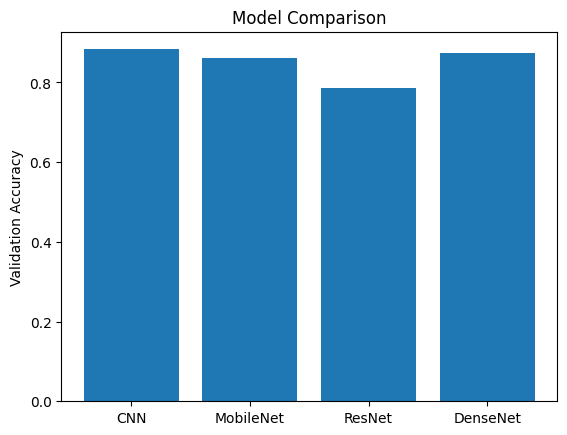

In [ ]:
models = ['CNN', 'MobileNet', 'ResNet', 'DenseNet']

accuracies = [
    max(history.history['val_accuracy']),
    max(history_mobilenet.history['val_accuracy']),
    max(history_resnet.history['val_accuracy']),
    max(history_dense.history['val_accuracy'])
]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Validation Accuracy")
plt.show()

In [ ]:
# rebuild model as functional (fixes your error permanently)
model_input = tf.keras.Input(shape=(224,224,3))
x = model_input

for layer in model.layers:
    x = layer(x)

model_fixed = tf.keras.Model(inputs=model_input, outputs=x)

In [ ]:
last_conv_layer = None
for layer in model.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

print("Last Conv Layer:", last_conv_layer)

Last Conv Layer: conv2d_5


In [ ]:
model_to_use = model_mobilenet

In [ ]:
last_conv_layer = None
for layer in model_to_use.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

print("Using layer:", last_conv_layer)

Using layer: Conv_1


In [ ]:
def get_gradcam(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    return heatmap

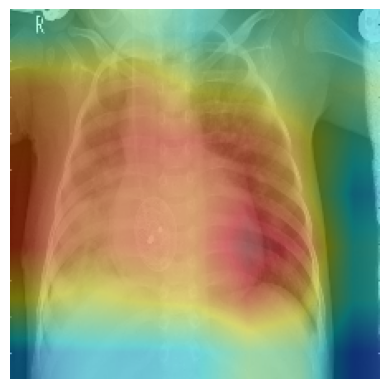

In [ ]:
img_path = test_dir + "/PNEUMONIA/" + os.listdir(test_dir + "/PNEUMONIA")[0]

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
img_array = np.expand_dims(img/255.0, axis=0)

heatmap = get_gradcam(img_array, model_to_use, last_conv_layer)

overlay_heatmap(img_path, heatmap)

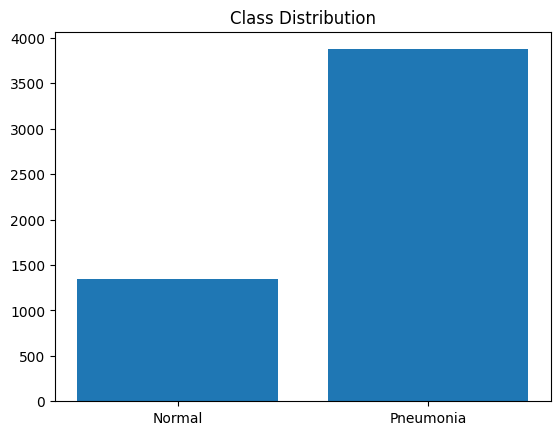

In [ ]:
import os

normal = len(os.listdir(train_dir + "/NORMAL"))
pneumonia = len(os.listdir(train_dir + "/PNEUMONIA"))

plt.bar(["Normal","Pneumonia"], [normal, pneumonia])
plt.title("Class Distribution")
plt.show()

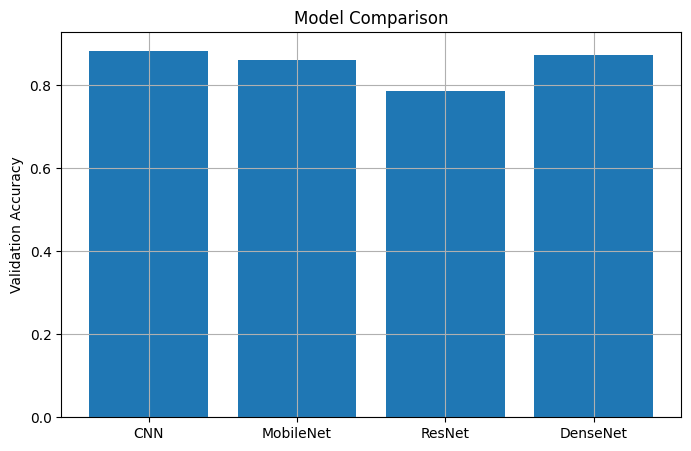

In [ ]:
models = ['CNN', 'MobileNet', 'ResNet', 'DenseNet']

accuracies = [
    max(history.history['val_accuracy']),
    max(history_mobilenet.history['val_accuracy']),
    max(history_resnet.history['val_accuracy']),
    max(history_dense.history['val_accuracy'])
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Validation Accuracy")
plt.grid()
plt.show()

In [ ]:
y_pred = model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int).flatten()

y_prob = model.predict(test_generator).flatten()



20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step


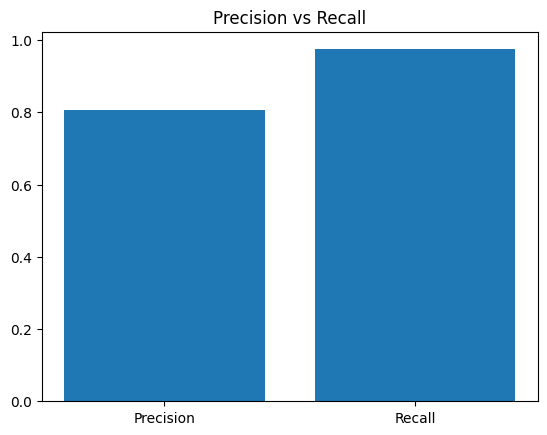

In [ ]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(test_generator.classes, y_pred)
recall = recall_score(test_generator.classes, y_pred)

plt.bar(["Precision","Recall"], [precision, recall])
plt.title("Precision vs Recall")
plt.show()

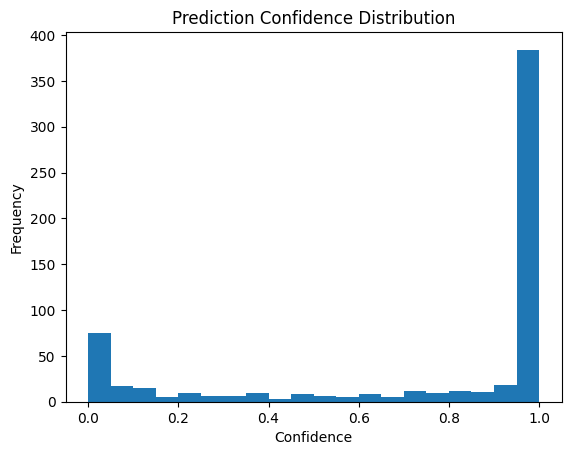

In [ ]:
plt.hist(y_prob, bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

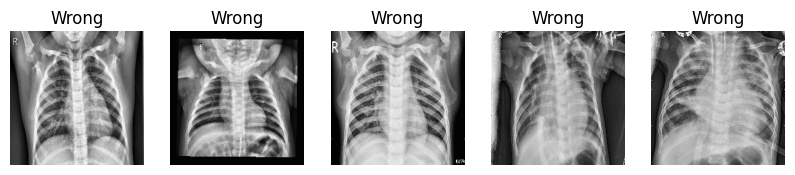

In [ ]:
misclassified = np.where(y_pred != test_generator.classes)[0]

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified[:5]):
    img, _ = test_generator[idx]
    plt.subplot(1,5,i+1)
    plt.imshow(img[0])
    plt.title("Wrong")
    plt.axis("off")
plt.show()

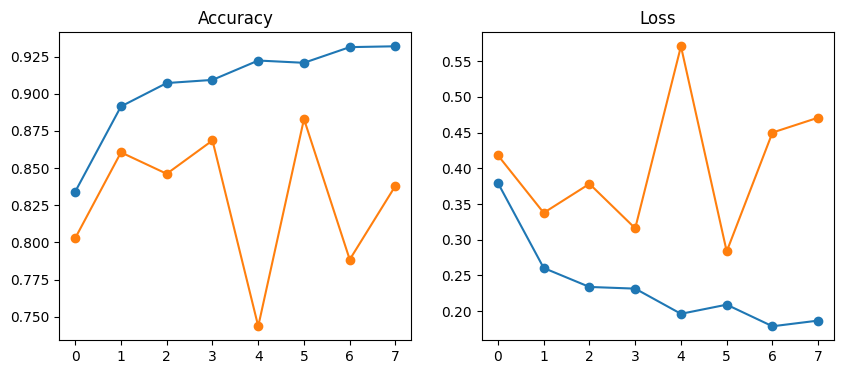

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')
plt.title("Loss")

plt.show()

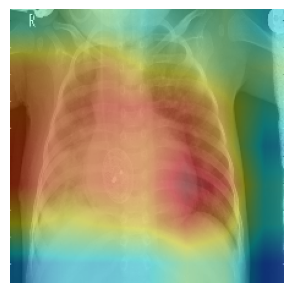

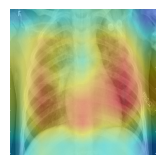

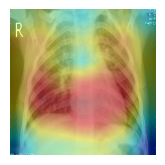

In [ ]:
plt.figure(figsize=(12,5))

for i in range(3):
    img_path = test_dir + "/PNEUMONIA/" + os.listdir(test_dir + "/PNEUMONIA")[i]

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img_array = np.expand_dims(img/255.0, axis=0)

    heatmap = get_gradcam(img_array, model_to_use, last_conv_layer)

    plt.subplot(1,3,i+1)
    overlay_heatmap(img_path, heatmap)

Saving eXtmE1V2XgsjZK2JolVQ5g_Border_of_left_atrium.jpg to eXtmE1V2XgsjZK2JolVQ5g_Border_of_left_atrium.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: NORMAL
Confidence: 0.3134047


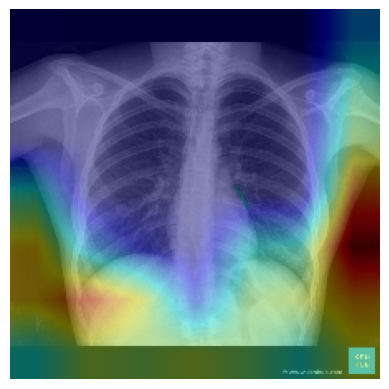

In [ ]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
img_array = np.expand_dims(img/255.0, axis=0)

pred = model_to_use.predict(img_array)[0][0]

label = "PNEUMONIA" if pred > 0.5 else "NORMAL"

print("Prediction:", label)
print("Confidence:", pred)

heatmap = get_gradcam(img_array, model_to_use, last_conv_layer)
overlay_heatmap(img_path, heatmap)

Saving ds00135_im00621_pnuesmal_gif.webp to ds00135_im00621_pnuesmal_gif.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
Prediction: PNEUMONIA
Confidence: 0.999999


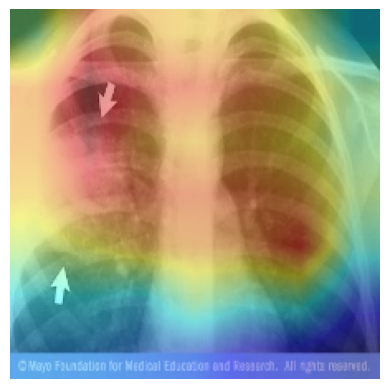

In [ ]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
img_array = np.expand_dims(img/255.0, axis=0)

pred = model_to_use.predict(img_array)[0][0]

label = "PNEUMONIA" if pred > 0.5 else "NORMAL"

print("Prediction:", label)
print("Confidence:", pred)

heatmap = get_gradcam(img_array, model_to_use, last_conv_layer)
overlay_heatmap(img_path, heatmap)